In [28]:
# ===============================
# 1. IMPORT LIBRARIES
# ===============================
import pandas as pd
import numpy as np
import re
from textblob import TextBlob
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
import torch
import torch.nn as nn
from transformers import BertTokenizer, BertModel

In [47]:
# ===============================
# 2. LOAD DATASET
# ===============================
# Make sure to upload 'Mental-Health-Twitter.csv' to your Colab session.
# A common location for uploaded files in Colab is '/content/'.
df = pd.read_csv("/content/Mental-Health-Twitter.csv")
df = df.sample(5000, random_state=42)

In [59]:
print(df['label'].unique())

[1 0]


In [60]:
print(df['label'].value_counts())

label
1    2524
0    2476
Name: count, dtype: int64


In [48]:
# ===============================
# 3. PREPROCESSING
# ===============================
def clean_text(text):
    text = re.sub(r"http\S+", "", str(text))
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    text = text.lower()
    return text

df['clean_text'] = df['post_text'].apply(clean_text)


In [49]:
# ===============================
# 4. EMOTION SCORING
# ===============================
def get_sentiment(text):
    return TextBlob(text).sentiment.polarity

df['emotion'] = df['clean_text'].apply(get_sentiment)

In [50]:
# ===============================
# 5. SORT BY USER + TIME
# ===============================
df['post_created'] = pd.to_datetime(df['post_created'])
df = df.sort_values(by=['user_id', 'post_created'])



/tmp/ipykernel_6018/1198741311.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['post_created'] = pd.to_datetime(df['post_created'])


In [51]:

# ===============================
# 6. EMOTIONAL DRIFT (ΔE)
# ===============================
df['drift'] = df.groupby('user_id')['emotion'].diff().fillna(0)

In [52]:

# 7. BERT TOKENIZATION
# ===============================
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

def tokenize(text):
    return tokenizer(
        text,
        padding='max_length',
        truncation=True,
        max_length=64,
        return_tensors='pt'
    )

df['tokens'] = df['clean_text'].apply(tokenize)


In [53]:
# ===============================
# 8. DATASET CLASS
# ===============================
class MentalHealthDataset(torch.utils.data.Dataset):
    def __init__(self, df):
        self.df = df.reset_index(drop=True)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        item = self.df.iloc[idx]
        tokens = item['tokens']
        return {
            'input_ids': tokens['input_ids'].squeeze(0),
            'attention_mask': tokens['attention_mask'].squeeze(0),
            'emotion': torch.tensor(item['emotion'], dtype=torch.float),
            'drift': torch.tensor(item['drift'], dtype=torch.float),
            'label': torch.tensor(item['label'], dtype=torch.float)
        }


In [76]:

# ===============================
# 9. TRAIN TEST SPLIT
# ===============================
train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df['label']
)

train_dataset = MentalHealthDataset(train_df)
test_dataset = MentalHealthDataset(test_df)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=16)

In [77]:

# ===============================
# 10. MODEL (BERT + BiLSTM)
# ===============================
class DriftModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.bert = BertModel.from_pretrained('bert-base-uncased')
        self.lstm = nn.LSTM(768 + 2, 128, batch_first=True, bidirectional=True)
        self.fc = nn.Linear(256, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, input_ids, attention_mask, emotion, drift):
        bert_out = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        x = bert_out.last_hidden_state[:, 0, :]  # CLS token

        extra = torch.stack((emotion, drift), dim=1)
        x = torch.cat((x, extra), dim=1)

        x = x.unsqueeze(1)
        lstm_out, _ = self.lstm(x)
        out = self.fc(lstm_out[:, -1, :])
        return self.sigmoid(out)



In [63]:

# ===============================
# 11. TRAINING
# ===============================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = DriftModel().to(device)

criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-5)

losses = []

for epoch in range(3):
    total_loss = 0

    model.train()

    for batch in train_loader:

        optimizer.zero_grad()   # ADD THIS

        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        emotion = batch['emotion'].to(device)
        drift = batch['drift'].to(device)
        labels = batch['label'].to(device)

        outputs = model(
            input_ids,
            attention_mask,
            emotion,
            drift
        ).squeeze()

        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        losses.append(loss.item())

    print(f"Epoch {epoch+1}, Loss: {total_loss}")



Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Epoch 1, Loss: 153.1136191189289
Epoch 2, Loss: 99.75783295929432
Epoch 3, Loss: 60.7008695602417


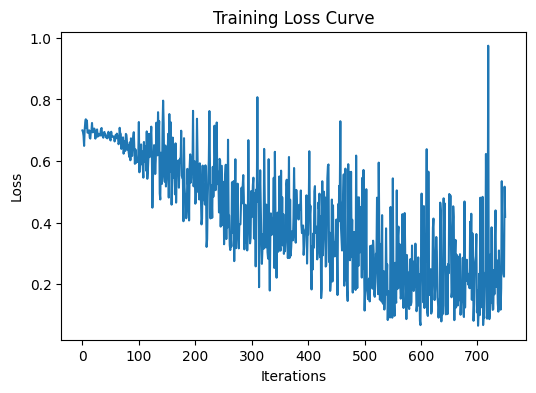

In [64]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

plt.plot(losses)

plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.title("Training Loss Curve")

plt.show()

In [65]:

# ===============================
# 12. EVALUATION
# ===============================
model.eval()
preds = []
true = []

with torch.no_grad():
    for batch in test_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        emotion = batch['emotion'].to(device)
        drift = batch['drift'].to(device)
        labels = batch['label'].to(device)

        outputs = model(input_ids, attention_mask, emotion, drift).squeeze()
        preds.extend(outputs.cpu().numpy())
        true.extend(labels.cpu().numpy())

preds = [1 if p > 0.5 else 0 for p in preds]

print("Accuracy:", accuracy_score(true, preds))
print(classification_report(true, preds))

Accuracy: 0.809
              precision    recall  f1-score   support

         0.0       0.80      0.80      0.80       483
         1.0       0.81      0.82      0.82       517

    accuracy                           0.81      1000
   macro avg       0.81      0.81      0.81      1000
weighted avg       0.81      0.81      0.81      1000



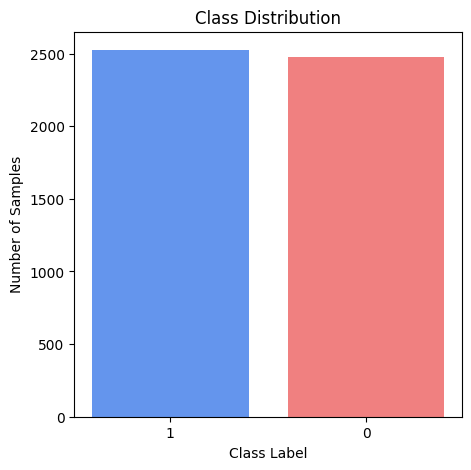

In [75]:
import matplotlib.pyplot as plt

counts = df['label'].value_counts()

colors = ['cornflowerblue', 'lightcoral']

plt.figure(figsize=(5,5))

plt.bar(counts.index.astype(str), counts.values, color=colors)

plt.xlabel("Class Label")
plt.ylabel("Number of Samples")
plt.title("Class Distribution")

plt.show()

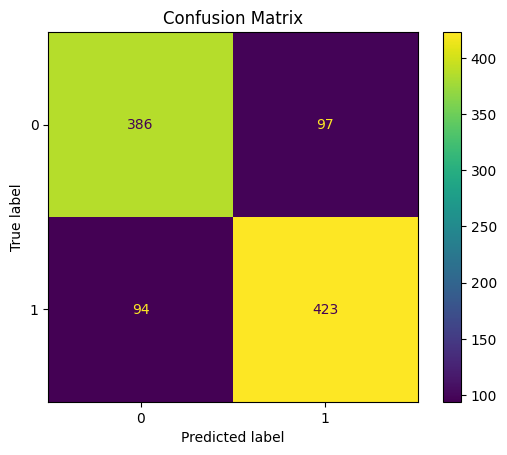

In [68]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Using the 'true' labels and 'preds' from the evaluation step
cm = confusion_matrix(true, preds)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.title("Confusion Matrix")
plt.show()

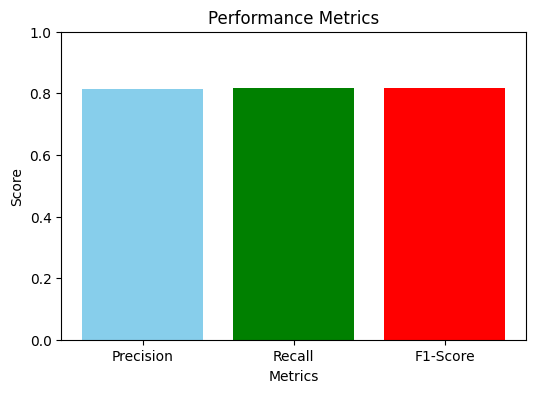

In [78]:
from sklearn.metrics import precision_score, recall_score, f1_score
import matplotlib.pyplot as plt

precision = precision_score(true, preds)
recall = recall_score(true, preds)
f1 = f1_score(true, preds)

metrics = ['Precision', 'Recall', 'F1-Score']
values = [precision, recall, f1]

colors = ['skyblue', 'green', 'red']

plt.figure(figsize=(6,4))

plt.bar(metrics, values, color=colors)

plt.ylim(0,1)

plt.xlabel("Metrics")
plt.ylabel("Score")
plt.title("Performance Metrics")

plt.show()